# Estimación del valor de mercado de futbolistas profesionales

## Notebook 2 — Análisis exploratorio y modelización

**Trabajo Fin de Máster** · Máster en Big Data, Data Science e Inteligencia Artificial · Universidad Complutense de Madrid

---

### Qué hace este notebook

| | |
|---|---|
| **Consume** | `data/processed/dataset_analitico.parquet` (salida del notebook 1) |
| **Produce** | Modelos entrenados, tabla comparativa de métricas y el pipeline final serializado |
| **Alimenta** | Capítulos 3 (Análisis exploratorio) y 5 (Modelización) de la memoria |
| **Siguiente** | `03_interpretabilidad.ipynb` |

### Estructura

1. **Análisis exploratorio** — sobre la unidad de análisis real: el jugador-temporada
2. **Especificaciones del modelo** — tres conjuntos de variables con propósitos distintos
3. **Preprocesado** — un tratamiento por familia de algoritmo, siempre dentro del pipeline
4. **Estrategia de validación** — partición temporal, agrupación por jugador y métricas
5. **Modelos** — cinco técnicas en progresión de complejidad
6. **Resultados** — comparativa, análisis de error y selección del modelo final

### Nota metodológica

La ingeniería de características se realizó en el notebook 1, ya que las variables derivadas
requieren las tablas en crudo. Lo que aquí se aplica es **preprocesado** —imputación,
escalado y codificación— que va necesariamente dentro del pipeline para que se ajuste
únicamente con los datos de entrenamiento.

**No se realiza selección de variables previa.** Seleccionar variables observando el
rendimiento en validación y reportar después sobre prueba contaminaría la evaluación. Se
emplean tres conjuntos fijos definidos por criterio metodológico, y se deja que cada
algoritmo gestione la irrelevancia con sus propios mecanismos.


---
## 0. Configuración

In [2]:
from pathlib import Path
import random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = PROJ / "data" / "processed"
MODELS    = PROJ / "models"
FIGURES   = PROJ / "reports" / "figures"
for p in (MODELS, FIGURES): p.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

a = pd.read_parquet(PROCESSED / "dataset_analitico.parquet")
print(f"{a.shape[0]:,} filas x {a.shape[1]} columnas | "
      f"{a['player_id'].nunique():,} jugadores distintos")
print(a.groupby("split").size().reindex(["train","valid","test"]).to_string())

12,861 filas x 41 columnas | 4,543 jugadores distintos
split
train    9186
valid    1831
test     1844


In [3]:
%load_ext watermark
%watermark -v -m -p pandas,numpy,scikit-learn,statsmodels,catboost,shap

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 9.16.1

pandas      : 3.0.5
numpy       : 2.4.6
scikit-learn: 1.9.0
statsmodels : 0.14.6
catboost    : 1.2.10
shap        : 0.51.0

Compiler    : MSC v.1942 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : AMD64 Family 23 Model 96 Stepping 1, AuthenticAMD
CPU cores   : 16
Architecture: 64bit



---
# 1. Análisis exploratorio

La exploración se realiza sobre el **dataset analítico**, no sobre las tablas en crudo. La
razón es que la unidad de análisis del estudio es el jugador-temporada, y esa unidad no
existe en los datos de origen: describir `appearances` sería caracterizar partidos
individuales, un objeto que el modelo nunca llega a ver.

Cada figura de esta sección justifica una decisión posterior.

## 1.1. Descriptivos generales

In [4]:
NUM_DESC = ["edad", "minutos", "partidos", "goles", "asistencias", "ga_90",
            "ratio_titular", "club_ppp", "club_rank", "club_valor_medio",
            "log_mv_prev", "target_valor"]

desc = a[NUM_DESC].describe(percentiles=[.01, .25, .5, .75, .99]).T
print("=== VARIABLES NUMÉRICAS ===")
print(desc[["count","mean","std","min","1%","50%","99%","max"]].round(2).to_string())

print("\n=== VARIABLES CATEGÓRICAS ===")
for c in ["position", "sub_position", "foot", "liga"]:
    print(f"\n{c} ({a[c].nunique()} valores):")
    print(a[c].value_counts(dropna=False).to_string())

print("\n=== EL OBJETIVO EN EUROS ===")
q = a["target_valor"].quantile([.01, .25, .5, .75, .99])
print(q.apply(lambda x: f"{x:,.0f} €").to_string())
print(f"\nRatio percentil 99 / percentil 1: {q.loc[.99]/q.loc[.01]:.0f}x")

=== VARIABLES NUMÉRICAS ===
                      count           mean            std         min          1%           50%            99%             max
edad             12,861.000         27.010          4.090      16.800      19.220        26.790         36.820          43.630
minutos          12,861.000      1,811.220        831.780     450.000     474.600     1,770.000      3,751.400       4,348.000
partidos         12,861.000         26.440          8.860       5.000       8.000        27.000         46.000          55.000
goles            12,861.000          2.860          4.330       0.000       0.000         1.000         20.000          49.000
asistencias      12,861.000          2.210          2.730       0.000       0.000         1.000         12.000          25.000
ga_90            12,861.000          0.240          0.240       0.000       0.000         0.170          0.990           2.700
ratio_titular    12,861.000          0.630          0.240       0.000       0.130  

## 1.2. Figura 1 — Distribución del objetivo

El valor de mercado presenta una asimetría extrema. Sin transformar, cualquier modelo
no rendirá correctamente.

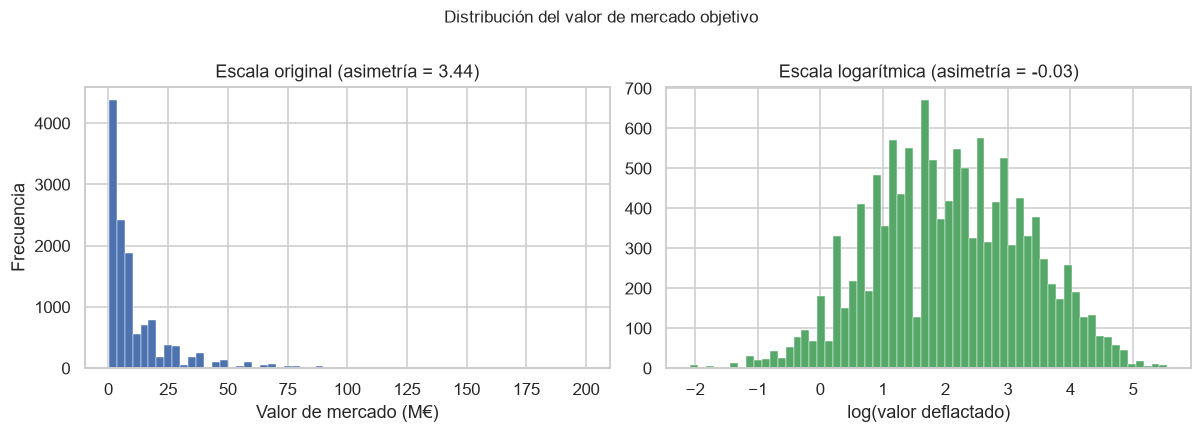

Asimetría original    :   3.44
Asimetría log nominal :  -0.03
Asimetría log deflact.:  -0.03   <- objetivo modelado


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].hist(a["target_valor"] / 1e6, bins=60, color="#4C72B0", edgecolor="white", lw=.3)
ax[0].set_xlabel("Valor de mercado (M€)"); ax[0].set_ylabel("Frecuencia")
ax[0].set_title(f"Escala original (asimetría = {a['target_valor'].skew():.2f})")

ax[1].hist(a["y_log_defl"], bins=60, color="#55A868", edgecolor="white", lw=.3)
ax[1].set_xlabel("log(valor deflactado)"); ax[1].set_ylabel("")
ax[1].set_title(f"Escala logarítmica (asimetría = {a['y_log_defl'].skew():.2f})")

fig.suptitle("Distribución del valor de mercado objetivo", y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig1_distribucion_target.png", bbox_inches="tight")
plt.show()

print(f"Asimetría original    : {a['target_valor'].skew():>6.2f}")
print(f"Asimetría log nominal : {a['y_log'].skew():>6.2f}")
print(f"Asimetría log deflact.: {a['y_log_defl'].skew():>6.2f}   <- objetivo modelado")

## 1.3. Figura 2 — La curva de valor por edad

La relación entre edad y valor no es monótona. Presenta una fase de revalorización durante los primeros años de carrera, un máximo situado en el entorno de los veinticuatro a veintisiete años, y un declive posterior pronunciado.
Esta forma es determinante para la elección de modelos: una regresión lineal sin transformar asumiría erróneamente que la edad penaliza o premia el valor de manera constante, lo que es falso. De hecho, la correlación lineal entre edad y valor logarítmico es reducida pese a tratarse de uno de los factores más influyentes, precisamente porque la relación es no monótona.
De aquí se derivan dos decisiones de modelado: la incorporación de “splines cúbicos naturales” sobre la edad en el modelo lineal, y el recurso a modelos basados en árboles, capaces de capturar la forma sin especificarla previamente.


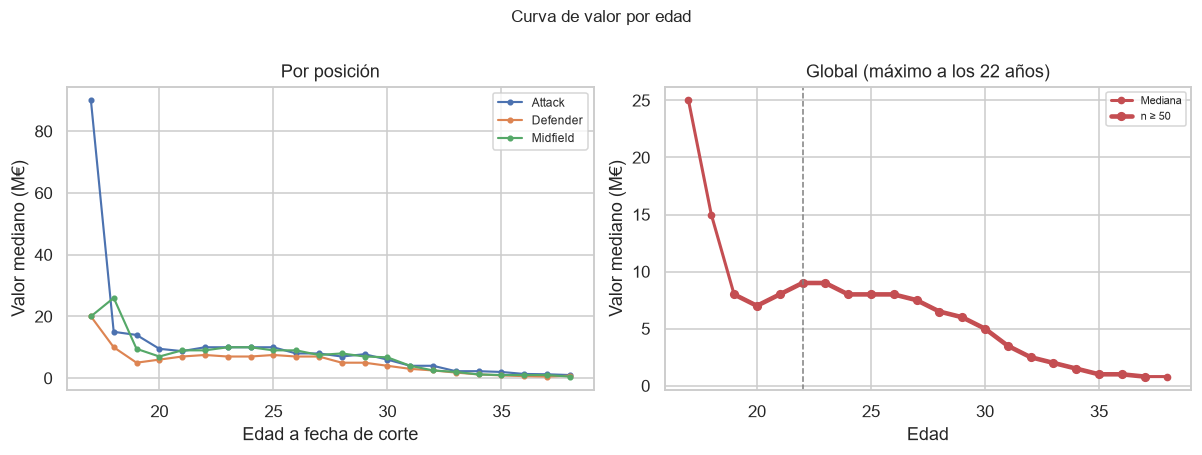

Edad de valor máximo (con n >= 50): 22 años
Correlación lineal edad-valor (log): -0.373  <- baja pese a ser determinante

Observaciones por edad (extremos del rango):
e
17.000      4
18.000     42
19.000    150
20.000    322
21.000    564
22.000    777
38.000     38
39.000     20
40.000     10
41.000      8
42.000      2
44.000      1


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for pos, g in a.groupby("position"):
    c = (g.assign(e=g["edad"].round()).groupby("e")["target_valor"].median() / 1e6)
    c = c[(c.index >= 17) & (c.index <= 38)]
    ax[0].plot(c.index, c.values, marker="o", ms=3, lw=1.4, label=pos)

ax[0].set_xlabel("Edad a fecha de corte"); ax[0].set_ylabel("Valor mediano (M€)")
ax[0].set_title("Por posición"); ax[0].legend(fontsize=8)

glob = a.assign(e=a["edad"].round()).groupby("e")["target_valor"]
med, n = glob.median()/1e6, glob.size()

# Se exige un mínimo de observaciones por edad: los extremos del rango
# contienen muy pocos jugadores y su mediana no es representativa.
MIN_N = 50
valida = med[(med.index >= 18) & (med.index <= 37) & (n >= MIN_N)]
edad_pico = int(valida.idxmax())

ax[1].plot(med.index[(med.index>=17)&(med.index<=38)],
           med.values[(med.index>=17)&(med.index<=38)],
           color="#C44E52", lw=2, marker="o", ms=4, label="Mediana")
ax[1].plot(valida.index, valida.values, color="#C44E52", lw=3, marker="o", ms=5,
           label=f"n ≥ {MIN_N}")
ax[1].axvline(edad_pico, ls="--", c="grey", lw=1)
ax[1].set_xlabel("Edad"); ax[1].set_ylabel("Valor mediano (M€)")
ax[1].set_title(f"Global (máximo a los {edad_pico} años)")
ax[1].legend(fontsize=7)

fig.suptitle("Curva de valor por edad", y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig2_curva_edad.png", bbox_inches="tight")
plt.show()

print(f"Edad de valor máximo (con n >= {MIN_N}): {edad_pico} años")
print(f"Correlación lineal edad-valor (log): "
      f"{np.corrcoef(a['edad'], a['y_log_defl'])[0,1]:.3f}  <- baja pese a ser determinante")

print(f"\nObservaciones por edad (extremos del rango):")
print(pd.concat([n.head(6), n.tail(6)]).to_string())

## 1.4. Figura 3 — Persistencia de la valoración

La valoración de un jugador en un año explica en gran medida la del año siguiente. 

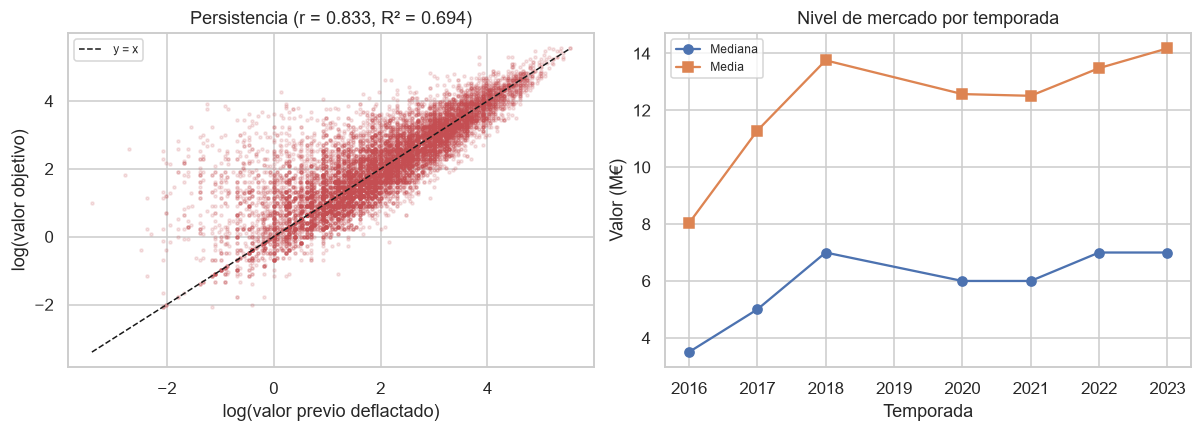

R² de persistencia: 0.694

Este es el listón real que deben superar los modelos.


In [7]:
sub = a.dropna(subset=["log_mv_prev"])
r = np.corrcoef(sub["log_mv_prev"], sub["y_log_defl"])[0, 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(sub["log_mv_prev"], sub["y_log_defl"], s=4, alpha=.15, color="#C44E52")
lim = [sub["log_mv_prev"].min(), sub["log_mv_prev"].max()]
ax[0].plot(lim, lim, "k--", lw=1, label="y = x")
ax[0].set_xlabel("log(valor previo deflactado)"); ax[0].set_ylabel("log(valor objetivo)")
ax[0].set_title(f"Persistencia (r = {r:.3f}, R² = {r**2:.3f})"); ax[0].legend(fontsize=8)

temp = a.groupby("season")["target_valor"].agg(["median", "mean"])
ax[1].plot(temp.index, temp["median"]/1e6, marker="o", label="Mediana")
ax[1].plot(temp.index, temp["mean"]/1e6, marker="s", label="Media")
ax[1].set_xlabel("Temporada"); ax[1].set_ylabel("Valor (M€)")
ax[1].set_title("Nivel de mercado por temporada"); ax[1].legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIGURES / "fig3_persistencia.png", bbox_inches="tight")
plt.show()

print(f"R² de persistencia: {r**2:.3f}")
print("\nEste es el listón real que deben superar los modelos.")

## 1.5. Figura 4 — Correlaciones entre predictores

Varios predictores miden aspectos muy próximos —minutos, partidos y titularidades reflejan
esencialmente la misma realidad—. Esta redundancia no impide el ajuste de los modelos basados
en árboles, pero **afecta a la interpretación**: los valores SHAP repartirán el crédito entre
variables correlacionadas, de modo que ninguna aparecerá como determinante por sí sola.

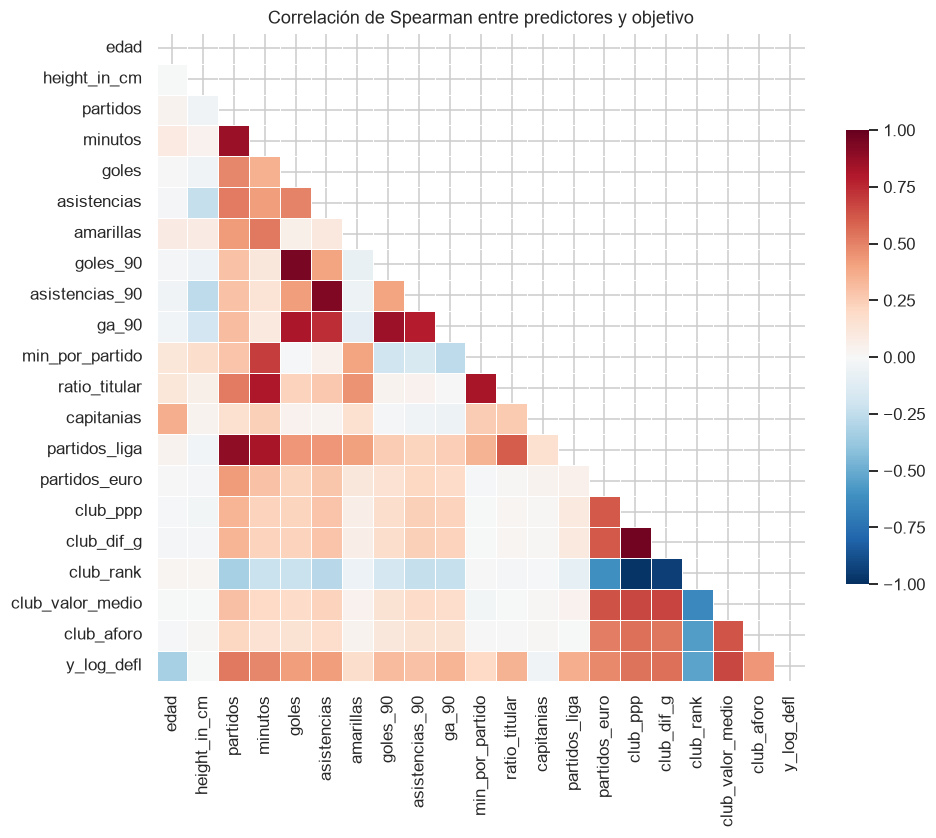

=== PARES MUY CORRELACIONADOS (|rho| > 0.80) ===
club_ppp         club_rank        0.982
                 club_dif_g       0.963
goles            goles_90         0.949
club_dif_g       club_rank        0.941
asistencias      asistencias_90   0.930
partidos         partidos_liga    0.890
                 minutos          0.865
goles_90         ga_90            0.854
min_por_partido  ratio_titular    0.828
minutos          partidos_liga    0.827
goles            ga_90            0.814
minutos          ratio_titular    0.806

=== CORRELACIÓN CON EL OBJETIVO (top 10) ===
club_valor_medio   0.671
club_dif_g         0.552
club_ppp           0.547
club_rank          0.531
partidos           0.527
minutos            0.488
partidos_euro      0.482
club_aforo         0.444
goles              0.421
asistencias        0.416


In [8]:
NUM_CORR = ["edad", "height_in_cm", "partidos", "minutos", "goles", "asistencias",
            "amarillas", "goles_90", "asistencias_90", "ga_90", "min_por_partido",
            "ratio_titular", "capitanias", "partidos_liga", "partidos_euro",
            "club_ppp", "club_dif_g", "club_rank", "club_valor_medio", "club_aforo",
            "y_log_defl"]
NUM_CORR = [c for c in NUM_CORR if c in a.columns]

corr = a[NUM_CORR].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Correlación de Spearman entre predictores y objetivo")
fig.tight_layout(); fig.savefig(FIGURES / "fig4_correlaciones.png", bbox_inches="tight")
plt.show()

print("=== PARES MUY CORRELACIONADOS (|rho| > 0.80) ===")
c2 = corr.drop(index="y_log_defl", columns="y_log_defl").abs()
pares = (c2.where(np.triu(np.ones(c2.shape), k=1).astype(bool))
           .stack().sort_values(ascending=False))
print(pares[pares > .80].round(3).to_string())

print("\n=== CORRELACIÓN CON EL OBJETIVO (top 10) ===")
print(corr["y_log_defl"].drop("y_log_defl").abs()
      .sort_values(ascending=False).head(10).round(3).to_string())

## 1.6. Figura 5 — El efecto del contexto de club

Un mismo rendimiento no se valora igual en cualquier equipo. Sin variables de contexto, el
modelo atribuiría al rendimiento individual lo que en realidad corresponde a la dimensión del
club en el que se juega.

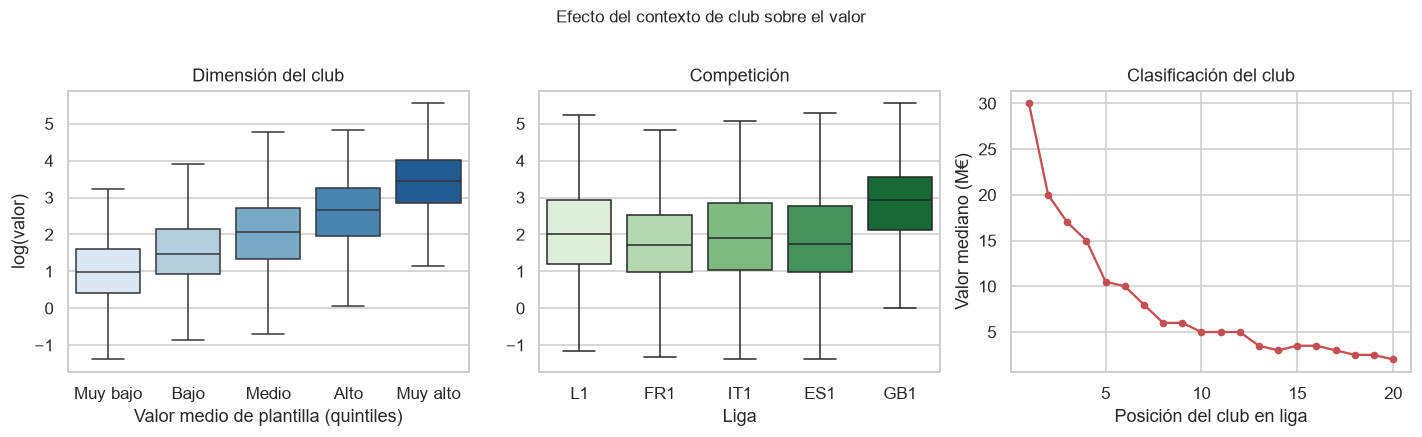

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

a["_tramo_club"] = pd.qcut(a["club_valor_medio"], 5,
                           labels=["Muy bajo","Bajo","Medio","Alto","Muy alto"])
sns.boxplot(data=a, x="_tramo_club", y="y_log_defl", ax=ax[0],
            showfliers=False, palette="Blues")
ax[0].set_xlabel("Valor medio de plantilla (quintiles)"); ax[0].set_ylabel("log(valor)")
ax[0].set_title("Dimensión del club")

sns.boxplot(data=a, x="liga", y="y_log_defl", ax=ax[1], showfliers=False, palette="Greens")
ax[1].set_xlabel("Liga"); ax[1].set_ylabel("")
ax[1].set_title("Competición")

rank = a.assign(r=a["club_rank"].round()).groupby("r")["target_valor"].median()/1e6
ax[2].plot(rank.index, rank.values, marker="o", ms=4, color="#C44E52")
ax[2].set_xlabel("Posición del club en liga"); ax[2].set_ylabel("Valor mediano (M€)")
ax[2].set_title("Clasificación del club")

fig.suptitle("Efecto del contexto de club sobre el valor", y=1.03)
fig.tight_layout(); fig.savefig(FIGURES / "fig5_contexto_club.png", bbox_inches="tight")
plt.show()

a.drop(columns="_tramo_club", inplace=True)

## 1.7. Valores ausentes y atípicos

En este problema los valores extremos son precisamente la parte más relevante. Un jugador de
200 M€ es un dato atípico en todas las variables, pero no es un error: recortarlo haría que el modelo dejase de saber valorar a los mejores jugadores, que es
donde se toman las decisiones económicamente más importantes.

La transformación logarítmica ya comprime la cola sin destruir información, y los modelos
basados en árboles son insensibles a los valores extremos de los predictores.

In [10]:
print("=== VALORES AUSENTES ===")
nul = a.isna().mean()
nul = (nul[nul > 0] * 100).round(2)
print(nul.to_string() if len(nul) else "  ninguno")

print("\n=== TRATAMIENTO PREVISTO ===")
print("  foot        -> categoría propia 'desconocido' (no se eliminan filas)")
print("  club_ppp    -> imputación por mediana dentro del pipeline")
print("  club_rank   -> imputación por mediana dentro del pipeline")
print("  log_mv_prev -> solo afecta a la especificación de robustez")

print("\n=== CASOS EXTREMOS EN RATIOS POR 90 MINUTOS ===")
print(a.nlargest(5, "ga_90")[["season","minutos","partidos","goles",
                              "asistencias","ga_90","target_valor"]].to_string(index=False))
print("\nSon jugadores con pocos minutos y alta participación: efecto de denominador")
print("pequeño, mitigado por el filtro de 450 minutos. No se corrigen.")

print("\n=== RANGOS DE LAS VARIABLES DERIVADAS ===")
for c in ["goles_90", "asistencias_90", "ga_90", "ratio_titular", "min_por_partido"]:
    print(f"  {c:<18} [{a[c].min():.3f}, {a[c].max():.3f}]")

=== VALORES AUSENTES ===
dias_mv_prev   1.170
height_in_cm   0.080
club_ppp       0.040
club_dif_g     0.040
club_rank      0.040
foot           0.120
log_mv_prev    1.170

=== TRATAMIENTO PREVISTO ===
  foot        -> categoría propia 'desconocido' (no se eliminan filas)
  club_ppp    -> imputación por mediana dentro del pipeline
  club_rank   -> imputación por mediana dentro del pipeline
  log_mv_prev -> solo afecta a la especificación de robustez

=== CASOS EXTREMOS EN RATIOS POR 90 MINUTOS ===
 season  minutos  partidos  goles  asistencias  ga_90    target_valor
   2021      467        24      9            5  2.698   3,000,000.000
   2018     3574        45     46           22  1.712 150,000,000.000
   2020     1881        42     23           10  1.579  30,000,000.000
   2022     3301        42     49            8  1.554 180,000,000.000
   2016     1586        32     19            8  1.532  35,000,000.000

Son jugadores con pocos minutos y alta participación: efecto de denominador


---
# 2. Especificaciones del modelo

Se definen tres conjuntos de variables. No responden a un proceso de selección automática,
sino a una decisión metodológica: cada uno responde a una pregunta distinta.

| Especificación | Variables | Pregunta que responde |
|---|---|---|
| **Persistencia** | Solo la valoración previa | ¿Cuánto se explica sin mirar el rendimiento? |
| **Principal** | Rendimiento, perfil y contexto de club | ¿Qué predice el rendimiento por sí solo? |
| **Robustez** | Todas las anteriores | ¿Cuál es el techo alcanzable? |

**La especificación principal es la del trabajo.** Excluye deliberadamente la valoración
previa porque, al capturar la persistencia del mercado, ocultaría la relación entre
rendimiento y valor, que es el objeto del estudio.

La especificación de robustez se reporta para cuantificar cuánta información adicional aporta
el historial de valoraciones, y sirve de referencia superior.

In [11]:
FEAT_NUM = ["edad", "height_in_cm",
            "partidos", "minutos", "goles", "asistencias", "amarillas", "rojas",
            "goles_90", "asistencias_90", "ga_90", "amarillas_90",
            "min_por_partido", "ratio_titular", "capitanias",
            "partidos_liga", "partidos_euro", "n_competiciones", "jugo_europa",
            "club_ppp", "club_dif_g", "club_rank", "club_valor_medio", "club_aforo"]
FEAT_CAT = ["position", "sub_position", "foot", "liga"]
FEAT_MV  = ["log_mv_prev"]

FEAT_NUM = [c for c in FEAT_NUM if c in a.columns]
FEAT_CAT = [c for c in FEAT_CAT if c in a.columns]

ESPECIFICACIONES = {
    "persistencia": {"num": FEAT_MV,            "cat": []},
    "principal":    {"num": FEAT_NUM,           "cat": FEAT_CAT},
    "robustez":     {"num": FEAT_NUM + FEAT_MV, "cat": FEAT_CAT},
}

for nombre, esp in ESPECIFICACIONES.items():
    print(f"{nombre:<14} {len(esp['num']):>2} numéricas + {len(esp['cat'])} categóricas")

TARGET = "y_log_defl"
GRUPO  = "player_id"

persistencia    1 numéricas + 0 categóricas
principal      24 numéricas + 4 categóricas
robustez       25 numéricas + 4 categóricas


## 2.1. Preparación de los conjuntos

Las categóricas ausentes se convierten en una categoría explícita `"desconocido"` en lugar de
eliminar las filas correspondientes. Perder observaciones por un dato de perfil menor sería
desproporcionado.

In [12]:
d = a.copy()
for c in FEAT_CAT:
    d[c] = d[c].fillna("desconocido").astype(str)

# La especificación de robustez requiere valoración previa
print(f"Filas sin log_mv_prev: {d['log_mv_prev'].isna().sum()} "
      f"({d['log_mv_prev'].isna().mean():.2%})")

tr = d[d.split == "train"].reset_index(drop=True)
va = d[d.split == "valid"].reset_index(drop=True)
te = d[d.split == "test" ].reset_index(drop=True)

print(f"\ntrain {len(tr):>6,} filas | {tr[GRUPO].nunique():>5,} jugadores | "
      f"temporadas {sorted(tr.season.unique())}")
print(f"valid {len(va):>6,} filas | {va[GRUPO].nunique():>5,} jugadores | "
      f"temporadas {sorted(va.season.unique())}")
print(f"test  {len(te):>6,} filas | {te[GRUPO].nunique():>5,} jugadores | "
      f"temporadas {sorted(te.season.unique())}")

comunes = set(tr[GRUPO]) & set(te[GRUPO])
print(f"\nJugadores presentes en train y test: {len(comunes):,}")
print("Es esperable y correcto: la separación es temporal, no por jugador.")
print("Por ello la validación cruzada dentro de train agrupa por player_id.")

Filas sin log_mv_prev: 150 (1.17%)

train  9,186 filas | 3,754 jugadores | temporadas [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021)]
valid  1,831 filas | 1,831 jugadores | temporadas [np.int64(2022)]
test   1,844 filas | 1,844 jugadores | temporadas [np.int64(2023)]

Jugadores presentes en train y test: 1,205
Es esperable y correcto: la separación es temporal, no por jugador.
Por ello la validación cruzada dentro de train agrupa por player_id.


---
# 3. Estrategia de validación y métricas

## 3.1. Por qué la partición no puede ser aleatoria

Existen dos motivos independientes, y ambos se controlan:

**Motivo temporal.** Un reparto aleatorio situaría temporadas futuras en entrenamiento y
pasadas en prueba. El modelo dispondría de información sobre la evolución del mercado que en
un uso real no tendría. La partición es por temporadas completas.

**Motivo de agrupación.** El conjunto contiene medidas repetidas: 4.372 jugadores generan
11.048 filas, unas 2,5 temporadas por jugador. Un reparto aleatorio situaría al mismo jugador
en entrenamiento y en prueba, y el modelo memorizaría individuos en lugar de aprender la
relación entre rendimiento y valor. Por ello la validación cruzada dentro de entrenamiento
emplea `GroupKFold` agrupando por `player_id`.

## 3.2. Métricas

No se emplea el coeficiente de determinación como métrica única. Se reportan:

| Métrica | Qué mide |
|---|---|
| `MAE_log`, `RMSE_log` | Error en la escala en la que se optimiza |
| `R2_log` | Proporción de varianza explicada |
| `MAE_eur`, `MedAE_eur` | Error retrotransformado a euros, interpretable |
| `MAPE_%` | Error relativo medio |
| `Spearman` | Calidad del **ordenamiento**, relevante para el ranking del notebook 3 |

**Sobre la retrotransformación.** Al deshacer el logaritmo mediante la función exponencial se
obtiene una estimación de la mediana condicionada, no de la media, lo que produce una
subestimación sistemática. Se aplica la corrección de Duan (*smearing estimator*), que ajusta
el resultado mediante el promedio de las exponenciales de los residuos de entrenamiento.

In [13]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

CV = GroupKFold(n_splits=5)

def a_euros(y_log, indice, factor_duan=1.0):
    # y = ln(V) - ln(I)  =>  V = exp(y) * I, con correccion de Duan.
    # Se fuerza numpy para evitar alineacion por indice de pandas.
    return np.exp(np.asarray(y_log)) * factor_duan * np.asarray(indice)

def duan(residuos_train):
    # Smearing estimator: corrige el sesgo de la retrotransformación
    return float(np.mean(np.exp(residuos_train)))

def evalua(nombre, especificacion, conjunto, y_true_log, y_pred_log,
           indice, y_true_eur, factor=1.0):
    pred_eur = a_euros(y_pred_log, indice, factor)
    err_rel  = np.abs(pred_eur - y_true_eur) / y_true_eur
    return {
        "modelo": nombre, "espec": especificacion, "conjunto": conjunto,
        "MAE_log":   mean_absolute_error(y_true_log, y_pred_log),
        "RMSE_log":  np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "R2_log":    r2_score(y_true_log, y_pred_log),
        "MAE_eur":   np.mean(np.abs(pred_eur - y_true_eur)),
        "MedAE_eur": np.median(np.abs(pred_eur - y_true_eur)),
        "MAPE_%":    100 * np.mean(err_rel),
        "Spearman":  spearmanr(y_true_log, y_pred_log).statistic,
    }

RESULTADOS = []

def registra(*args, **kwargs):
    r = evalua(*args, **kwargs)
    RESULTADOS.append(r)
    print(f"  {r['conjunto']:<6} MAE_log {r['MAE_log']:.4f} | R2 {r['R2_log']:.4f} | "
          f"MAE {r['MAE_eur']/1e6:>6.2f} M€ | MAPE {r['MAPE_%']:>6.1f}% | "
          f"rho {r['Spearman']:.4f}")
    return r

print("Funciones de evaluación definidas.")

Funciones de evaluación definidas.


## 3.3. Demostración empírica del sesgo de la partición aleatoria

Antes de entrenar los modelos definitivos se cuantifica el efecto de emplear una partición
incorrecta. Se ajusta el mismo algoritmo con la misma configuración bajo dos esquemas:
partición aleatoria por filas frente a partición temporal con agrupación por jugador.

La diferencia entre ambos resultados cuantifica el optimismo que introduciría una
evaluación mal diseñada. Su magnitud depende del solapamiento de jugadores entre
particiones, por lo que el resultado obtenido —cualquiera que sea— es en sí mismo
informativo sobre la naturaleza del problema.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def prep_arboles(num, cat):
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="desconocido")),
                          ("enc", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                 unknown_value=-1))]), cat),
    ], remainder="drop")

esp = ESPECIFICACIONES["principal"]
COLS = esp["num"] + esp["cat"]
rf_demo = lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                        n_jobs=-1, random_state=SEED)

# --- Esquema A: partición aleatoria por filas (INCORRECTO) -------------------
Xa, ya = d[COLS], d[TARGET]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=.2, random_state=SEED)
pipe_a = Pipeline([("prep", prep_arboles(esp["num"], esp["cat"])), ("m", rf_demo())])
pipe_a.fit(Xa_tr, ya_tr)
r2_aleatorio = r2_score(ya_te, pipe_a.predict(Xa_te))

# --- Esquema B: partición temporal + agrupación (CORRECTO) ------------------
pipe_b = Pipeline([("prep", prep_arboles(esp["num"], esp["cat"])), ("m", rf_demo())])
pipe_b.fit(tr[COLS], tr[TARGET])
r2_temporal = r2_score(te[TARGET], pipe_b.predict(te[COLS]))

print("=== EFECTO DEL DISEÑO DE VALIDACIÓN (Random Forest, especificación principal) ===")
print(f"  Partición aleatoria por filas   R² = {r2_aleatorio:.4f}")
print(f"  Partición temporal + agrupación R² = {r2_temporal:.4f}")
print(f"\n  Optimismo introducido: {r2_aleatorio - r2_temporal:+.4f} "
      f"({100*(r2_aleatorio-r2_temporal)/max(r2_temporal,1e-9):+.1f}%)")
print("\nTodas las métricas de este trabajo se reportan bajo el esquema correcto.")

=== EFECTO DEL DISEÑO DE VALIDACIÓN (Random Forest, especificación principal) ===
  Partición aleatoria por filas   R² = 0.8592
  Partición temporal + agrupación R² = 0.8183

  Optimismo introducido: +0.0409 (+5.0%)

Todas las métricas de este trabajo se reportan bajo el esquema correcto.


---
# 4. Modelos

Se entrenan cinco técnicas en progresión de complejidad. La comparación no busca únicamente
identificar el mejor resultado, sino documentar las fortalezas y debilidades de cada familia
sobre este problema concreto.

| # | Modelo | Papel en el análisis |
|---|---|---|
| 1 | Persistencia | Baseline realista, no trivial |
| 2 | Regresión lineal con splines | Referencia interpretable, coeficientes con lectura económica |
| 3 | Random Forest | Primer modelo no lineal, con ajuste de hiperparámetros |
| 4 | CatBoost | Modelo final, con ajuste y estimación de intervalos |
| 5 | Red neuronal con embeddings | Contraste con aprendizaje profundo |

## 4.1. Modelo 1 — Persistencia

El baseline no es un predictor constante, sino la regla que un observador informado aplicaría:
un jugador valdrá aproximadamente lo mismo que el año anterior.

In [15]:
from sklearn.dummy import DummyRegressor

print("=== MODELO 1a: predictor constante (mediana) ===")
dum = DummyRegressor(strategy="median").fit(tr[COLS], tr[TARGET])
for nom, cj in [("valid", va), ("test", te)]:
    registra("Constante (mediana)", "—", nom, cj[TARGET],
             dum.predict(cj[COLS]), cj["indice_mercado"], cj["target_valor"])

print("\n=== MODELO 1b: persistencia (V_t+1 = V_t) ===")
for nom, cj in [("valid", va), ("test", te)]:
    m = cj["log_mv_prev"].notna()
    sub_ = cj[m]
    registra("Persistencia", "persistencia", nom, sub_[TARGET],
             sub_["log_mv_prev"].values, sub_["indice_mercado"], sub_["target_valor"])

=== MODELO 1a: predictor constante (mediana) ===
  valid  MAE_log 1.0039 | R2 -0.0289 | MAE  10.44 M€ | MAPE  128.9% | rho nan
  test   MAE_log 1.0305 | R2 -0.0596 | MAE  11.20 M€ | MAPE  116.1% | rho nan

=== MODELO 1b: persistencia (V_t+1 = V_t) ===
  valid  MAE_log 0.4762 | R2 0.6481 | MAE   4.94 M€ | MAPE   44.4% | rho 0.8486
  test   MAE_log 0.5125 | R2 0.5590 | MAE   4.75 M€ | MAPE   44.8% | rho 0.8164


## 4.2. Modelo 2 — Regresión lineal con splines de edad

La edad se modela mediante splines cúbicos naturale, lo que permite capturar la curva de
carrera —no monótona, con un máximo intermedio— dentro de un marco lineal.

In [16]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables continuas cuya relación con el objetivo es plausiblemente multiplicativa
LOG_VARS = ["minutos", "club_valor_medio", "club_aforo"]

def prepara_ols(dfx):
    x = dfx.copy()
    for c in LOG_VARS:
        x[f"log_{c}"] = np.log1p(x[c])
    return x

tr_ols, va_ols, te_ols = prepara_ols(tr), prepara_ols(va), prepara_ols(te)

TERMINOS = ["log_minutos", "goles_90", "asistencias_90", "amarillas_90",
            "ratio_titular", "min_por_partido", "capitanias",
            "partidos_euro", "n_competiciones",
            "club_ppp", "club_rank", "log_club_valor_medio", "log_club_aforo",
            "height_in_cm"]

# Spline cúbico natural sobre la edad; si 'cr' no está disponible, se usa 'bs'
for spline in ["cr(edad, df=5)", "bs(edad, df=5)"]:
    formula = f"{TARGET} ~ {spline} + " + " + ".join(TERMINOS) + \
              " + C(position) + C(foot) + C(liga)"
    try:
        ols = smf.ols(formula, data=tr_ols).fit()
        print(f"Spline empleado: {spline}")
        break
    except Exception as e:
        print(f"  {spline} no disponible ({type(e).__name__})")

print(f"\nR² ajustado (train): {ols.rsquared_adj:.4f} | AIC: {ols.aic:,.0f}")
print(f"Observaciones: {int(ols.nobs):,}")

print("\n=== COEFICIENTES SIGNIFICATIVOS (p < 0.01), sin splines ni dummies ===")
res = pd.DataFrame({"coef": ols.params, "p": ols.pvalues})
res = res[~res.index.str.contains(r"edad|Intercept|C\(")]
print(res[res["p"] < .01].sort_values("coef", key=abs, ascending=False).round(4).to_string())

print("\n=== VIF (multicolinealidad) ===")
Xv = tr_ols[[c for c in TERMINOS]].dropna()
vif = pd.DataFrame({"variable": Xv.columns,
                    "VIF": [variance_inflation_factor(Xv.values, i)
                            for i in range(Xv.shape[1])]})
print(vif.sort_values("VIF", ascending=False).round(2).to_string(index=False))
print("\nVIF > 10 indica multicolinealidad relevante.")

Spline empleado: cr(edad, df=5)

R² ajustado (train): 0.8454 | AIC: 12,885
Observaciones: 9,174

=== COEFICIENTES SIGNIFICATIVOS (p < 0.01), sin splines ni dummies ===
                       coef     p
ratio_titular         1.384 0.000
goles_90              1.026 0.000
log_club_valor_medio  0.555 0.000
asistencias_90        0.503 0.000
club_ppp              0.453 0.000
log_minutos           0.383 0.000
log_club_aforo        0.053 0.000
height_in_cm          0.003 0.001
capitanias            0.002 0.007
min_por_partido      -0.002 0.004

=== VIF (multicolinealidad) ===
            variable     VIF
log_club_valor_medio 703.350
      log_club_aforo 626.750
        height_in_cm 625.640
         log_minutos 571.840
            club_ppp 115.120
     min_por_partido  75.630
           club_rank  43.360
       ratio_titular  42.080
     n_competiciones  13.700
       partidos_euro   3.440
        amarillas_90   3.340
      asistencias_90   2.490
            goles_90   2.140
          capitania

In [17]:
# Corrección de Duan sobre los residuos de entrenamiento
factor_ols = duan(ols.resid.values)
print(f"Factor de Duan (OLS): {factor_ols:.4f}")

print("\n=== MODELO 2: OLS con splines ===")
for nom, cj in [("valid", va_ols), ("test", te_ols)]:
    pred = ols.predict(cj)
    m = pred.notna()
    registra("OLS + splines", "principal", nom, cj.loc[m, TARGET], pred[m],
             cj.loc[m, "indice_mercado"], cj.loc[m, "target_valor"], factor_ols)

Factor de Duan (OLS): 1.1238

=== MODELO 2: OLS con splines ===
  valid  MAE_log 0.3717 | R2 0.8432 | MAE   4.07 M€ | MAPE   39.5% | rho 0.9256
  test   MAE_log 0.3929 | R2 0.8270 | MAE   4.33 M€ | MAPE   38.2% | rho 0.9196


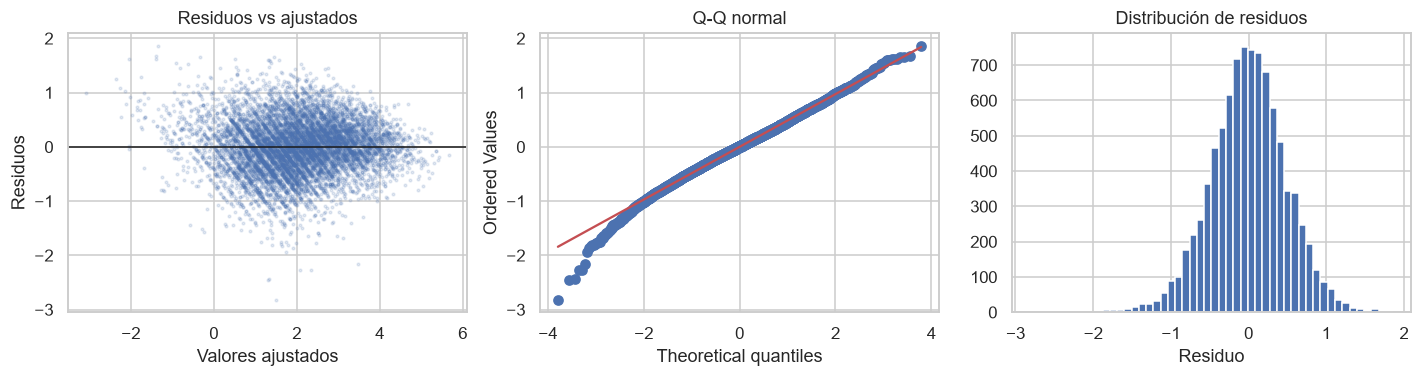

Breusch-Pagan: estadístico 623.2, p-valor 2.03e-113
p < 0.05 indica heterocedasticidad: los errores estándar clásicos
deben interpretarse con cautela.


In [18]:
# Diagnóstico de residuos (Anexo)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

ax[0].scatter(ols.fittedvalues, ols.resid, s=3, alpha=.15)
ax[0].axhline(0, c="k", lw=1); ax[0].set_xlabel("Valores ajustados")
ax[0].set_ylabel("Residuos"); ax[0].set_title("Residuos vs ajustados")

import scipy.stats as st
st.probplot(ols.resid, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q normal")

ax[2].hist(ols.resid, bins=50, color="#4C72B0"); ax[2].set_title("Distribución de residuos")
ax[2].set_xlabel("Residuo")

fig.tight_layout(); fig.savefig(FIGURES / "figA_diagnostico_ols.png", bbox_inches="tight")
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(ols.resid, ols.model.exog)
print(f"Breusch-Pagan: estadístico {bp[0]:.1f}, p-valor {bp[1]:.3g}")
print("p < 0.05 indica heterocedasticidad: los errores estándar clásicos")
print("deben interpretarse con cautela.")

## 4.3. Modelo 3 — Random Forest

Primer modelo capaz de capturar relaciones no lineales e interacciones sin especificarlas.
Los hiperparámetros se ajustan mediante búsqueda aleatoria con validación cruzada.
Se entrena bajo las tres especificaciones para cuantificar la aportación de cada bloque de
información.

In [19]:
PARAMS_RF = {
    "persistencia": {"n_estimators": 300, "min_samples_split": 2,
                     "min_samples_leaf": 4, "max_features": 0.6, "max_depth": 12},
    "principal":    {"n_estimators": 500, "min_samples_split": 2,
                     "min_samples_leaf": 2, "max_features": 0.6, "max_depth": None},
    "robustez":     {"n_estimators": 500, "min_samples_split": 2,
                     "min_samples_leaf": 2, "max_features": 0.6, "max_depth": 25},
}

modelos_rf = {}
for nombre_esp in ["persistencia", "principal", "robustez"]:
    print(f"\n=== RANDOM FOREST — especificación '{nombre_esp}' ===")
    esp  = ESPECIFICACIONES[nombre_esp]
    cols = esp["num"] + esp["cat"]
    trx  = tr.dropna(subset=esp["num"]) if nombre_esp != "principal" else tr

    modelo = Pipeline([
        ("prep", prep_arboles(esp["num"], esp["cat"])),
        ("m", RandomForestRegressor(**PARAMS_RF[nombre_esp],
                                    n_jobs=-1, random_state=SEED))])
    t0 = time.time()
    modelo.fit(trx[cols], trx[TARGET])
    print(f"  entrenado en {time.time()-t0:.0f}s")

    factor = duan((trx[TARGET] - modelo.predict(trx[cols])).values)
    modelos_rf[nombre_esp] = (modelo, cols, factor)

    for nom, cj in [("valid", va), ("test", te)]:
        cjx = cj
        registra("Random Forest", nombre_esp, nom, cjx[TARGET],
                 modelo.predict(cjx[cols]), cjx["indice_mercado"],
                 cjx["target_valor"], factor)


=== RANDOM FOREST — especificación 'persistencia' ===
  entrenado en 1s
  valid  MAE_log 0.4929 | R2 0.7033 | MAE   7.28 M€ | MAPE   83.2% | rho 0.8430
  test   MAE_log 0.5173 | R2 0.6542 | MAE   6.37 M€ | MAPE   78.8% | rho 0.8066

=== RANDOM FOREST — especificación 'principal' ===
  entrenado en 3s
  valid  MAE_log 0.3812 | R2 0.8401 | MAE   4.44 M€ | MAPE   38.1% | rho 0.9195
  test   MAE_log 0.4078 | R2 0.8171 | MAE   5.13 M€ | MAPE   38.0% | rho 0.9128

=== RANDOM FOREST — especificación 'robustez' ===
  entrenado en 3s
  valid  MAE_log 0.2697 | R2 0.9062 | MAE   3.37 M€ | MAPE   27.3% | rho 0.9496
  test   MAE_log 0.2844 | R2 0.8957 | MAE   3.60 M€ | MAPE   27.9% | rho 0.9441


## 4.4. Modelo 4 — CatBoost

Se selecciona sobre otras implementaciones de *gradient boosting* por dos motivos: trata las
variables categóricas de forma nativa mediante *ordered target statistics*, evitando la
expansión que produciría una codificación one-hot y el sobreajuste asociado a una
codificación por objetivo construida manualmente; y su esquema de *ordered boosting* reduce
el sesgo de predicción en conjuntos de tamaño moderado como este.

In [20]:
from catboost import CatBoostRegressor, Pool

def pools(espec_nombre):
    esp  = ESPECIFICACIONES[espec_nombre]
    cols = esp["num"] + esp["cat"]
    idx  = [cols.index(c) for c in esp["cat"]]
    # No se descartan filas por ausencia de valoracion previa: CatBoost trata
    # los nulos de forma nativa y asi las tres especificaciones se evaluan
    # sobre exactamente el mismo conjunto de prueba.
    trx, vax, tex = (x.reset_index(drop=True) for x in (tr, va, te))
    P = lambda x: Pool(x[cols], x[TARGET], cat_features=idx)
    return P(trx), P(vax), P(tex), cols, esp, trx, vax, tex

# Hiperparámetros obtenidos en una búsqueda aleatoria previa (20 combinaciones,
# validación cruzada de 3 pliegues). Se reutilizan por el mismo motivo indicado
# para Random Forest.
PARAMS_CB = {
    "persistencia": {"subsample": 0.7,  "random_strength": 6, "depth": 10,
                     "learning_rate": 0.05, "l2_leaf_reg": 3},
    "principal":    {"subsample": 1,    "random_strength": 3, "depth": 8,
                     "learning_rate": 0.05, "l2_leaf_reg": 1},
    "robustez":     {"subsample": 0.85, "random_strength": 3, "depth": 8,
                     "learning_rate": 0.02, "l2_leaf_reg": 3},
}

modelos_cb = {}
for nombre_esp in ["persistencia", "principal", "robustez"]:
    print(f"\n=== CATBOOST — especificación '{nombre_esp}' ===")
    p_tr, p_va, p_te, cols, esp, trx, vax, tex = pools(nombre_esp)

    modelo = CatBoostRegressor(**PARAMS_CB[nombre_esp], iterations=3000,
                               loss_function="RMSE", eval_metric="MAE",
                               random_seed=SEED, od_type="Iter", od_wait=100,
                               verbose=0)
    t0 = time.time()
    modelo.fit(p_tr, eval_set=p_va, use_best_model=True)
    print(f"  entrenado en {time.time()-t0:.0f}s | "
          f"iteraciones óptimas: {modelo.get_best_iteration()}")

    factor = duan((trx[TARGET] - modelo.predict(p_tr)).values)
    modelos_cb[nombre_esp] = (modelo, cols, esp, factor)

    for nom, cj, pl_ in [("valid", vax, p_va), ("test", tex, p_te)]:
        registra("CatBoost", nombre_esp, nom, cj[TARGET], modelo.predict(pl_),
                 cj["indice_mercado"], cj["target_valor"], factor)


=== CATBOOST — especificación 'persistencia' ===
  entrenado en 2s | iteraciones óptimas: 97
  valid  MAE_log 0.4719 | R2 0.7204 | MAE   6.22 M€ | MAPE   75.6% | rho 0.8443
  test   MAE_log 0.4953 | R2 0.6708 | MAE   5.94 M€ | MAPE   71.9% | rho 0.8081

=== CATBOOST — especificación 'principal' ===
  entrenado en 54s | iteraciones óptimas: 764
  valid  MAE_log 0.3489 | R2 0.8634 | MAE   3.77 M€ | MAPE   33.7% | rho 0.9337
  test   MAE_log 0.3849 | R2 0.8366 | MAE   4.37 M€ | MAPE   34.6% | rho 0.9277

=== CATBOOST — especificación 'robustez' ===
  entrenado en 124s | iteraciones óptimas: 1833
  valid  MAE_log 0.2377 | R2 0.9300 | MAE   2.77 M€ | MAPE   23.2% | rho 0.9649
  test   MAE_log 0.2563 | R2 0.9180 | MAE   2.98 M€ | MAPE   23.7% | rho 0.9597


### Intervalos de predicción

Una valoración expresada como un único número transmite una precisión que el modelo no posee.
Se entrenan tres modelos con función de pérdida cuantílica —cuantiles 0,1, 0,5 y 0,9— que
permiten acompañar cada estimación de un intervalo con una cobertura nominal del 80 %.

La cobertura empírica sobre el conjunto de prueba verifica si el intervalo cumple lo que
promete.

In [21]:
p_tr, p_va, p_te, cols, esp, trx, vax, tex = pools("principal")
assert "log_mv_prev" not in cols, "Los cuantiles deben usar la especificacion principal"

cuantiles = {}
for q in [0.1, 0.5, 0.9]:
    m = CatBoostRegressor(iterations=1200, loss_function=f"Quantile:alpha={q}",
                          depth=6, learning_rate=0.05, random_seed=SEED, verbose=0)
    m.fit(p_tr, eval_set=p_va, use_best_model=True)
    cuantiles[q] = m
    print(f"  cuantil {q}: entrenado")

lo, med, hi = (cuantiles[q].predict(p_te) for q in [0.1, 0.5, 0.9])

# Los tres cuantiles se entrenan por separado y pueden cruzarse.
# Se fuerza la monotonía, práctica habitual en regresión cuantílica.
cruces = (lo > med) | (med > hi)
print(f"Cruces de cuantiles corregidos: {cruces.sum()} de {len(lo)} ({cruces.mean():.1%})")
lo, med, hi = np.sort(np.vstack([lo, med, hi]), axis=0)

dentro = ((tex[TARGET] >= lo) & (tex[TARGET] <= hi)).mean()
print(f"\nCobertura empírica del intervalo 80%: {dentro:.1%}")
print(f"Amplitud mediana (escala log): {np.median(hi - lo):.3f}")

lo_e  = a_euros(lo,  tex["indice_mercado"])
med_e = a_euros(med, tex["indice_mercado"])
hi_e  = a_euros(hi,  tex["indice_mercado"])
print(f"Amplitud mediana en euros: {np.median(hi_e - lo_e)/1e6:.2f} M€")

  cuantil 0.1: entrenado
  cuantil 0.5: entrenado
  cuantil 0.9: entrenado
Cruces de cuantiles corregidos: 11 de 1844 (0.6%)

Cobertura empírica del intervalo 80%: 73.5%
Amplitud mediana (escala log): 1.079
Amplitud mediana en euros: 7.28 M€


In [22]:
orden = np.argsort(tex["target_valor"].values)
pos = orden[np.linspace(0, len(orden)-1, 6).astype(int)]

ej = tex.iloc[pos].reset_index(drop=True)
ej["inf_M€"]  = np.asarray(lo_e)[pos]  / 1e6
ej["pred_M€"] = np.asarray(med_e)[pos] / 1e6
ej["sup_M€"]  = np.asarray(hi_e)[pos]  / 1e6
ej["real_M€"] = ej["target_valor"].values / 1e6
ej["acierta"] = (ej["real_M€"] >= ej["inf_M€"]) & (ej["real_M€"] <= ej["sup_M€"])

print("\nEjemplos de predicción con intervalo:")
print(ej[["season","edad","position","liga","inf_M€","pred_M€","sup_M€",
          "real_M€","acierta"]].round(2).to_string(index=False))


Ejemplos de predicción con intervalo:
 season   edad position liga  inf_M€  pred_M€  sup_M€  real_M€  acierta
   2023 37.700 Defender  FR1   0.270    0.320   0.820    0.250    False
   2023 22.920 Midfield  IT1   2.360    3.550  11.420    2.500     True
   2023 22.270 Defender  IT1   1.350    3.350   7.750    5.000     True
   2023 27.580 Defender   L1   5.270    7.720  15.350   10.000     True
   2023 26.600 Defender  GB1   6.460   13.450  20.120   20.000     True
   2023 25.360   Attack  FR1  86.450  118.270 125.450  180.000    False


## 4.5. Modelo 5 — Red neuronal con embeddings de entidades

Se anticipa que este modelo no obtendrá el mejor resultado. En problemas tabulares de
tamaño moderado, los métodos de *boosting* superan habitualmente a las redes neuronales. Su
inclusión responde a un motivo: documentar empíricamente esa diferencia sobre el problema
concreto.

In [23]:
try:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    TORCH = True
    torch.manual_seed(SEED)
except ImportError:
    TORCH = False
    print("PyTorch no disponible: se omite el modelo 5.")

In [24]:
if TORCH:
    from sklearn.preprocessing import StandardScaler

    esp  = ESPECIFICACIONES["principal"]
    NUMc, CATc = esp["num"], esp["cat"]

    # Codificación de categóricas a índices, ajustada solo con train
    mapas = {c: {v: i for i, v in enumerate(sorted(tr[c].unique()))} for c in CATc}
    cards = {c: len(m) + 1 for c, m in mapas.items()}      # +1 para desconocidos

    def idx_cat(dfx):
        return np.stack([dfx[c].map(mapas[c]).fillna(len(mapas[c])).astype(int).values
                         for c in CATc], axis=1)

    imp = tr[NUMc].median()
    sc  = StandardScaler().fit(tr[NUMc].fillna(imp))
    Xn  = lambda dfx: sc.transform(dfx[NUMc].fillna(imp)).astype(np.float32)

    def tensores(dfx):
        return (torch.tensor(Xn(dfx)), torch.tensor(idx_cat(dfx)),
                torch.tensor(dfx[TARGET].values, dtype=torch.float32))

    Xtr_n, Xtr_c, ytr = tensores(tr)
    Xva_n, Xva_c, yva = tensores(va)
    Xte_n, Xte_c, yte = tensores(te)

    class MLPEmb(nn.Module):
        def __init__(self, n_num, cards, oculto=(128, 64), p=0.25):
            super().__init__()
            self.emb = nn.ModuleList([
                nn.Embedding(card, min(16, (card + 1) // 2)) for card in cards.values()])
            dim_emb = sum(e.embedding_dim for e in self.emb)
            capas, entrada = [], n_num + dim_emb
            for h in oculto:
                capas += [nn.Linear(entrada, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
                entrada = h
            capas.append(nn.Linear(entrada, 1))
            self.red = nn.Sequential(*capas)

        def forward(self, xn, xc):
            e = torch.cat([emb(xc[:, i]) for i, emb in enumerate(self.emb)], dim=1)
            return self.red(torch.cat([xn, e], dim=1)).squeeze(-1)

    red = MLPEmb(len(NUMc), cards)
    opt = torch.optim.AdamW(red.parameters(), lr=2e-3, weight_decay=1e-4)
    perdida = nn.L1Loss()
    loader = DataLoader(TensorDataset(Xtr_n, Xtr_c, ytr), batch_size=256, shuffle=True)

    mejor, paciencia, espera = np.inf, 25, 0
    for epoca in range(300):
        red.train()
        for bn, bc, by in loader:
            opt.zero_grad(); perdida(red(bn, bc), by).backward(); opt.step()
        red.eval()
        with torch.no_grad():
            mae_va = perdida(red(Xva_n, Xva_c), yva).item()
        if mae_va < mejor - 1e-4:
            mejor, espera = mae_va, 0
            estado = {k: v.clone() for k, v in red.state_dict().items()}
        else:
            espera += 1
            if espera >= paciencia:
                print(f"  parada temprana en época {epoca} | mejor MAE(valid) = {mejor:.4f}")
                break
    red.load_state_dict(estado)

  parada temprana en época 189 | mejor MAE(valid) = 0.3418


In [25]:
if TORCH:
    red.eval()
    with torch.no_grad():
        p_tr_ = red(Xtr_n, Xtr_c).numpy()
        p_va_ = red(Xva_n, Xva_c).numpy()
        p_te_ = red(Xte_n, Xte_c).numpy()

    factor_nn = duan(tr[TARGET].values - p_tr_)
    print("=== MODELO 5: red neuronal con embeddings ===")
    for nom, cj, pr in [("valid", va, p_va_), ("test", te, p_te_)]:
        registra("MLP + embeddings", "principal", nom, cj[TARGET], pr,
                 cj["indice_mercado"], cj["target_valor"], factor_nn)

=== MODELO 5: red neuronal con embeddings ===
  valid  MAE_log 0.3418 | R2 0.8659 | MAE   3.94 M€ | MAPE   34.1% | rho 0.9322
  test   MAE_log 0.3794 | R2 0.8365 | MAE   4.39 M€ | MAPE   34.5% | rho 0.9247


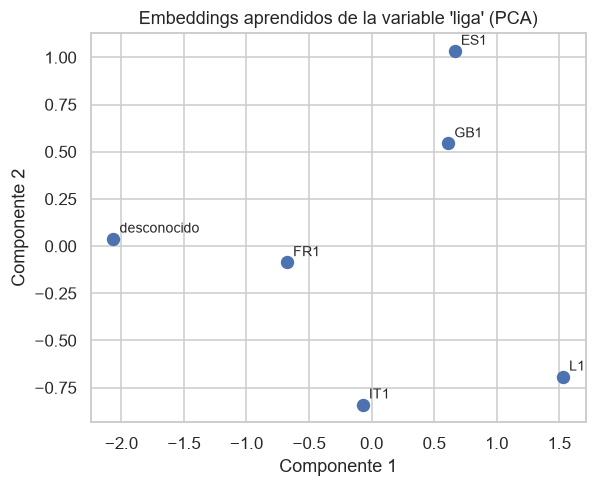

Distancias entre ligas en el espacio latente:
              ES1   FR1   GB1   IT1    L1  desconocido
ES1         0.000 1.780 1.560 2.200 1.930        2.920
FR1         1.780 0.000 1.840 1.130 2.300        1.390
GB1         1.560 1.840 0.000 1.650 2.100        2.950
IT1         2.200 1.130 1.650 0.000 1.820        2.250
L1          1.930 2.300 2.100 1.820 0.000        3.680
desconocido 2.920 1.390 2.950 2.250 3.680        0.000


In [26]:
if TORCH:
    # Los embeddings aprendidos son un resultado interpretable en sí mismos
    i_liga = CATc.index("liga")
    E = red.emb[i_liga].weight.detach().numpy()
    etiquetas = list(sorted(tr["liga"].unique())) + ["desconocido"]

    from sklearn.decomposition import PCA
    P = PCA(n_components=2, random_state=SEED).fit_transform(E)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.scatter(P[:, 0], P[:, 1], s=60, c="#4C72B0")
    for (x, y), t in zip(P, etiquetas):
        ax.annotate(t, (x, y), fontsize=9, xytext=(4, 4), textcoords="offset points")
    ax.set_title("Embeddings aprendidos de la variable 'liga' (PCA)")
    ax.set_xlabel("Componente 1"); ax.set_ylabel("Componente 2")
    fig.tight_layout(); fig.savefig(FIGURES / "fig6_embeddings_liga.png", bbox_inches="tight")
    plt.show()

    print("Distancias entre ligas en el espacio latente:")
    from scipy.spatial.distance import pdist, squareform
    D = pd.DataFrame(squareform(pdist(E)), index=etiquetas, columns=etiquetas)
    print(D.round(2).to_string())

---
# 5. Resultados

## 5.1. Tabla comparativa

La lectura debe hacerse **por especificación**. Comparar un modelo que incorpora la
valoración previa con otro que no lo hace no aporta información, ya que resuelven problemas
de dificultad distinta.

In [27]:
R = pd.DataFrame(RESULTADOS)
R.to_csv(PROCESSED / "resultados_modelos.csv", index=False, encoding="utf-8")

for cj in ["valid", "test"]:
    print(f"\n{'='*95}\nCONJUNTO: {cj.upper()}\n{'='*95}")
    t = (R[R.conjunto == cj]
         .sort_values(["espec", "MAE_log"])
         [["espec","modelo","MAE_log","RMSE_log","R2_log",
           "MAE_eur","MedAE_eur","MAPE_%","Spearman"]])
    t["MAE_eur"]   = (t["MAE_eur"]/1e6).round(2)
    t["MedAE_eur"] = (t["MedAE_eur"]/1e6).round(2)
    print(t.rename(columns={"MAE_eur":"MAE_M€","MedAE_eur":"MedAE_M€"})
           .round(4).to_string(index=False))


CONJUNTO: VALID
       espec              modelo  MAE_log  RMSE_log  R2_log  MAE_M€  MedAE_M€  MAPE_%  Spearman
persistencia            CatBoost    0.472     0.634   0.720   6.220     3.170  75.618     0.844
persistencia        Persistencia    0.476     0.712   0.648   4.940     2.000  44.429     0.849
persistencia       Random Forest    0.493     0.653   0.703   7.280     3.810  83.236     0.843
   principal    MLP + embeddings    0.342     0.439   0.866   3.940     1.630  34.071     0.932
   principal            CatBoost    0.349     0.443   0.863   3.770     1.730  33.666     0.934
   principal       OLS + splines    0.372     0.475   0.843   4.070     1.850  39.538     0.926
   principal       Random Forest    0.381     0.480   0.840   4.440     1.780  38.059     0.919
    robustez            CatBoost    0.238     0.318   0.930   2.770     1.100  23.151     0.965
    robustez       Random Forest    0.270     0.367   0.906   3.370     1.280  27.303     0.950
           — Constante 

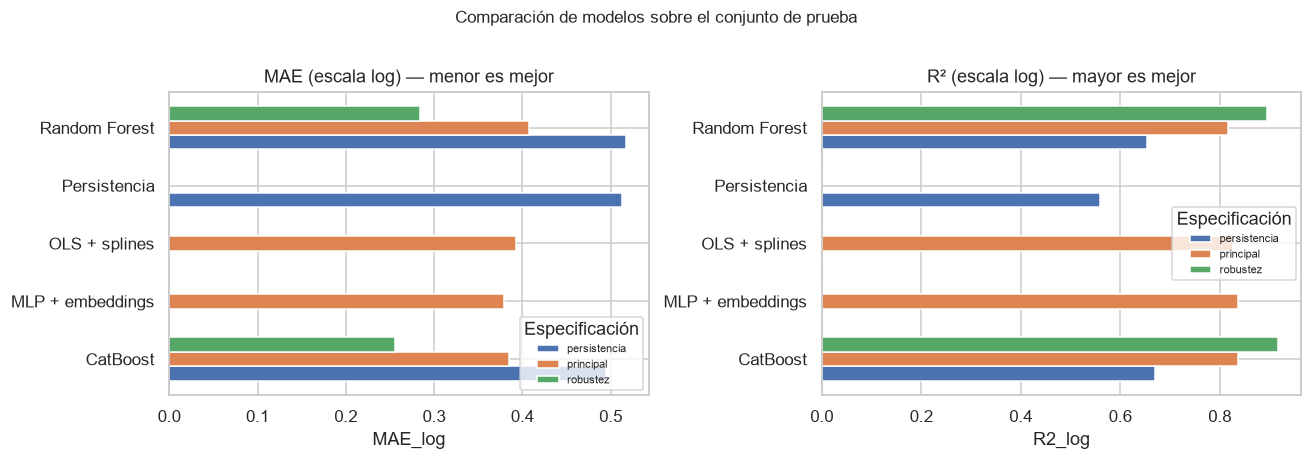

In [28]:
# Comparación gráfica sobre el conjunto de prueba
tt = R[(R.conjunto == "test") & (R.espec != "—")]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (met, tit) in enumerate([("MAE_log", "MAE (escala log) — menor es mejor"),
                                ("R2_log", "R² (escala log) — mayor es mejor")]):
    piv = tt.pivot_table(index="modelo", columns="espec", values=met)
    piv.plot(kind="barh", ax=ax[i], width=.75)
    ax[i].set_title(tit); ax[i].set_xlabel(met); ax[i].set_ylabel("")
    ax[i].legend(title="Especificación", fontsize=7)

fig.suptitle("Comparación de modelos sobre el conjunto de prueba", y=1.03)
fig.tight_layout(); fig.savefig(FIGURES / "fig7_comparativa.png", bbox_inches="tight")
plt.show()

## 5.2. Análisis del error por segmento

El error medio oculta comportamientos muy distintos según el tramo de valor. Se examina dónde
falla el modelo, cuestión que resulta determinante para el notebook 3: si el modelo
infravalora sistemáticamente a los jugadores más caros, los residuos negativos de ese tramo
reflejarán un sesgo del modelo y no una oportunidad de mercado.

In [29]:
modelo_f, cols_f, esp_f, factor_f = modelos_cb["principal"]
p_te_f = Pool(te[cols_f], te[TARGET], cat_features=[cols_f.index(c) for c in esp_f["cat"]])

te_an = te.copy()
te_an["pred_log"] = modelo_f.predict(p_te_f)
te_an["pred_eur"] = a_euros(te_an["pred_log"], te_an["indice_mercado"], factor_f)
te_an["residuo"]  = te_an[TARGET] - te_an["pred_log"]
te_an["err_abs"]  = te_an["residuo"].abs()
te_an["err_rel"]  = (te_an["pred_eur"] - te_an["target_valor"]).abs() / te_an["target_valor"]

te_an["tramo"] = pd.qcut(te_an["target_valor"], 5,
                         labels=["Muy bajo","Bajo","Medio","Alto","Muy alto"])

print("=== ERROR POR TRAMO DE VALOR ===")
print(te_an.groupby("tramo", observed=True)
      .agg(n=("residuo","size"),
           valor_mediano_M=("target_valor", lambda s: s.median()/1e6),
           MAE_log=("err_abs","mean"),
           sesgo_medio=("residuo","mean"),
           MAPE_pct=("err_rel", lambda s: 100*s.mean()))
      .round(3).to_string())

print("\nUn sesgo medio positivo indica INFRAVALORACIÓN sistemática del modelo.")

print("\n=== ERROR POR POSICIÓN ===")
print(te_an.groupby("position").agg(n=("residuo","size"), MAE_log=("err_abs","mean"),
                                    sesgo=("residuo","mean")).round(3).to_string())

print("\n=== ERROR POR LIGA ===")
print(te_an.groupby("liga").agg(n=("residuo","size"), MAE_log=("err_abs","mean"),
                                sesgo=("residuo","mean")).round(3).to_string())

print("\n=== ERROR POR TRAMO DE EDAD ===")
te_an["tramo_edad"] = pd.cut(te_an["edad"], [15,21,25,29,33,50],
                             labels=["<21","21-25","25-29","29-33",">33"])
print(te_an.groupby("tramo_edad", observed=True)
      .agg(n=("residuo","size"), MAE_log=("err_abs","mean"),
           sesgo=("residuo","mean")).round(3).to_string())

=== ERROR POR TRAMO DE VALOR ===
            n  valor_mediano_M  MAE_log  sesgo_medio  MAPE_pct
tramo                                                         
Muy bajo  447            1.700    0.363       -0.056    46.102
Bajo      352            4.000    0.335        0.128    31.061
Medio     362            8.000    0.380        0.253    31.110
Alto      315           15.000    0.431        0.365    31.387
Muy alto  368           35.000    0.424        0.388    30.365

Un sesgo medio positivo indica INFRAVALORACIÓN sistemática del modelo.

=== ERROR POR POSICIÓN ===
            n  MAE_log  sesgo
position                     
Attack    511    0.363  0.146
Defender  742    0.408  0.238
Midfield  591    0.374  0.200

=== ERROR POR LIGA ===
        n  MAE_log  sesgo
liga                     
ES1   404    0.415  0.176
FR1   326    0.397  0.210
GB1   383    0.397  0.209
IT1   401    0.376  0.200
L1    330    0.333  0.211

=== ERROR POR TRAMO DE EDAD ===
              n  MAE_log  sesgo
tramo

In [30]:
INTERIM = PROJ / "data" / "interim"
app_ = pd.read_parquet(INTERIM / "appearances.parquet")
gam_ = pd.read_parquet(INTERIM / "games.parquet")[["game_id", "season"]]
apps = app_.merge(gam_, on="game_id", how="left")

# 1. Apariciones GB1 en 2023?
ing = apps[(apps.season == 2023) & (apps.competition_id == "GB1")]
print(f"GB1 2023: {len(ing):,} apariciones | {ing.player_id.nunique():,} jugadores")

# 2. Cobertura GB1 por temporada
print("\nApariciones por liga y temporada:")
print(pd.crosstab(apps[apps.season.between(2016, 2023)]["season"],
                  apps[apps.season.between(2016, 2023)]["competition_id"]
                 )[["GB1","ES1","IT1","L1","FR1"]].to_string())

# 3. Esos jugadores, a que liga se les asigna en dataset final?
jug = set(ing.player_id)
sub = a[(a.season == 2023) & (a.player_id.isin(jug))]
print(f"\nJugadores GB1 2023 en dataset final: {len(sub):,}")
print(sub["liga"].value_counts(dropna=False).to_string() if len(sub) else "  ninguno")

GB1 2023: 11,384 apariciones | 570 jugadores

Apariciones por liga y temporada:
competition_id    GB1    ES1    IT1    L1    FR1
season                                          
2016            10474  10559  10607  8509  10496
2017            10447  10554  10587  8508  10515
2018            10454  10551  10549  8496  10523
2019            10578  10922  10956  8749   7710
2020            10356  11139  11622  9253  11456
2021            10369  11468  11456  9244  11217
2022            11345  11838  11885  9412  11529
2023            11384  11883  11910  9526   9394

Jugadores GB1 2023 en dataset final: 396
liga
GB1    382
L1       6
FR1      4
ES1      2
IT1      2


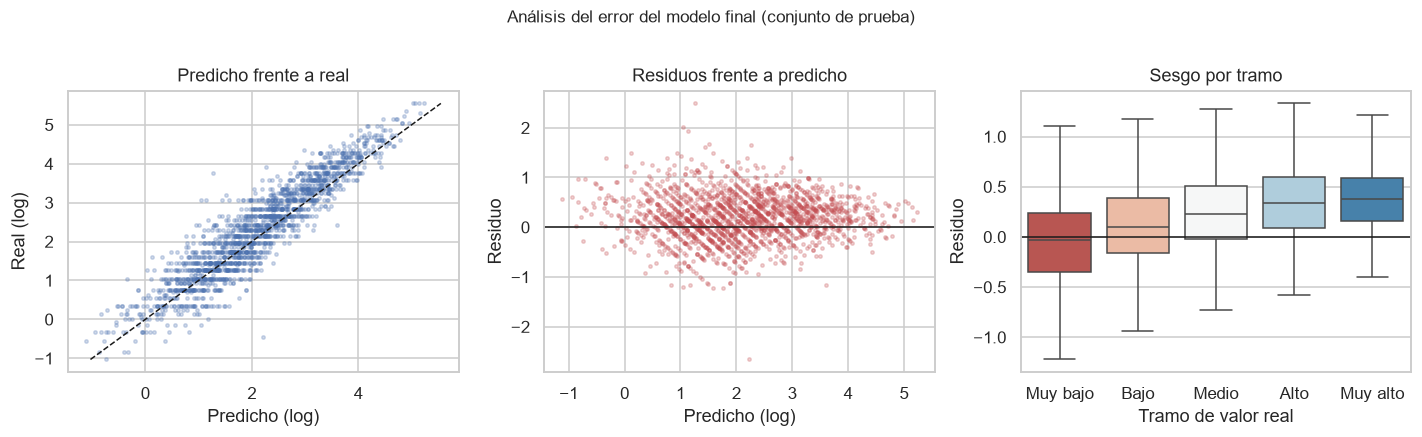

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

ax[0].scatter(te_an["pred_log"], te_an[TARGET], s=5, alpha=.25)
lim = [te_an[TARGET].min(), te_an[TARGET].max()]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_xlabel("Predicho (log)"); ax[0].set_ylabel("Real (log)")
ax[0].set_title("Predicho frente a real")

ax[1].scatter(te_an["pred_log"], te_an["residuo"], s=5, alpha=.25, color="#C44E52")
ax[1].axhline(0, c="k", lw=1)
ax[1].set_xlabel("Predicho (log)"); ax[1].set_ylabel("Residuo")
ax[1].set_title("Residuos frente a predicho")

sns.boxplot(data=te_an, x="tramo", y="residuo", ax=ax[2], showfliers=False, palette="RdBu")
ax[2].axhline(0, c="k", lw=1)
ax[2].set_xlabel("Tramo de valor real"); ax[2].set_ylabel("Residuo")
ax[2].set_title("Sesgo por tramo")

fig.suptitle("Análisis del error del modelo final (conjunto de prueba)", y=1.03)
fig.tight_layout(); fig.savefig(FIGURES / "fig8_analisis_error.png", bbox_inches="tight")
plt.show()

## 5.3. Selección del modelo final y serialización

Se conserva el modelo junto con toda la información necesaria para reproducir una predicción:
las columnas de entrada en su orden, los índices de las variables categóricas, el factor de
corrección de Duan y los modelos cuantílicos que proporcionan el intervalo.

Guardar el modelo aislado sería insuficiente: sin el factor de Duan y sin el índice de
mercado de la temporada, la predicción no puede convertirse a euros.

In [32]:
import joblib

artefacto = {
    "modelo":        modelos_cb["principal"][0],
    "columnas":      cols_f,
    "cat_features":  [cols_f.index(c) for c in esp_f["cat"]],
    "num_features":  esp_f["num"],
    "cat_nombres":   esp_f["cat"],
    "factor_duan":   factor_f,
    "cuantiles":     cuantiles,
    "indice_mercado": a.groupby("season")["target_valor"].median().to_dict(),
    "target":        TARGET,
    "seed":          SEED,
    "especificacion": "principal",
}
joblib.dump(artefacto, MODELS / "modelo_final.joblib")
print("Modelo serializado en", MODELS / "modelo_final.joblib")

# Los residuos alimentan el notebook 3
te_an.to_parquet(PROCESSED / "predicciones_test.parquet", index=False)
print("Predicciones de test guardadas para el notebook 3.")

joblib.dump({k: (v[0], v[1], v[2]) for k, v in modelos_rf.items()},
            MODELS / "modelos_rf.joblib")
print("Modelos Random Forest guardados.")

Modelo serializado en e:\PEPO\PEPO\MASTER\TFM\tfm_estimacionValorMercadoFutbolista\entrega\implementacion\src\models\modelo_final.joblib
Predicciones de test guardadas para el notebook 3.
Modelos Random Forest guardados.


---

## Cierre

**Ficheros generados:**

| Fichero | Contenido |
|---|---|
| `models/modelo_final.joblib` | Modelo, metadatos, factor de Duan y modelos cuantílicos |
| `models/modelos_rf.joblib` | Random Forest por especificación |
| `data/processed/resultados_modelos.csv` | Tabla comparativa completa |
| `data/processed/predicciones_test.parquet` | Predicciones y residuos sobre prueba |
| `reports/figures/*.png` | Figuras para la memoria |

**Continúa en `03_interpretabilidad.ipynb`**: interpretación mediante SHAP e identificación de jugadores infravalorados.